# Plant Disease Detection



Use this notebook to load the dataset, train a model, and evaluate results.


## Importing Libraries

In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preprocing

### Training Image Preprocessing

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    "../data/ PlantDisease/Dataset/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 70295 files belonging to 38 classes.


W0000 00:00:1787730608.876641    1821 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1787730609.062997    1821 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    "../data/ PlantDisease/Dataset/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 17572 files belonging to 38 classes.


In [5]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [7]:
for x , y in training_set:
    print(x)
    print(y)
    break

tf.Tensor(
[[[[137.   125.   139.  ]
   [129.25 117.25 131.25]
   [137.25 125.25 139.25]
   ...
   [127.25 116.25 132.25]
   [122.   111.   127.  ]
   [129.5  118.5  134.5 ]]

  [[135.   123.   137.  ]
   [142.   130.   144.  ]
   [125.25 113.25 127.25]
   ...
   [117.   106.   122.  ]
   [112.25 101.25 117.25]
   [123.25 112.25 128.25]]

  [[133.75 121.75 135.75]
   [129.   117.   131.  ]
   [133.25 121.25 135.25]
   ...
   [121.   110.   126.  ]
   [124.75 113.75 129.75]
   [131.25 120.25 136.25]]

  ...

  [[180.   170.   181.  ]
   [186.75 176.75 187.75]
   [175.75 165.75 176.75]
   ...
   [150.   139.   155.  ]
   [148.25 137.25 153.25]
   [142.75 131.75 147.75]]

  [[179.25 169.25 180.25]
   [178.5  168.5  179.5 ]
   [182.25 172.25 183.25]
   ...
   [146.25 135.25 151.25]
   [149.75 138.75 154.75]
   [148.25 137.25 153.25]]

  [[178.25 168.25 179.25]
   [176.25 166.25 177.25]
   [176.25 166.25 177.25]
   ...
   [144.25 133.25 149.25]
   [149.75 138.75 154.75]
   [145.25 134.25 15

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,Dropout,BatchNormalization,Input,Activation,SpatialDropout2D

In [7]:
model = Sequential()

### Building Model

In [8]:
model.add(Input(shape=(128,128,3)))

In [9]:
model.add(Conv2D(32, 3, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(32, 3, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=2, strides=2))

In [10]:
model.add(Conv2D(64, 3, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(64, 3, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=2, strides=2))

In [11]:
model.add(Conv2D(128, 3, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(128, 3, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=2, strides=2))

In [12]:
model.add(Conv2D(256, 3, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(Conv2D(256, 3, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))

model.add(MaxPooling2D(pool_size=2, strides=2))

In [13]:
model.add(SpatialDropout2D(0.25))

In [14]:
model.add(Flatten())

In [15]:
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation("relu"))

In [16]:
model.add(Dropout(0.4))

In [17]:
#output layer
model.add(Dense(units=38, activation="softmax"))

In [18]:
model.compile(optimizer="adam" , loss="categorical_crossentropy" , metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,16

 Total params: 3,278,790 (12.51 MB)

 Trainable params: 3,276,614 (12.50 MB)

 Non-trainable params: 2,176 (8.50 KB)

### Model Traning

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

In [21]:
training_history = model.fit(x=training_set,validation_data=validation_set, epochs=30,
    callbacks=[early_stop, reduce_lr])

Epoch 1/30


I0000 00:00:1787730731.405505    2630 service.cc:153] XLA service 0x784be004a210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787730731.405554    2630 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787730731.550927    2630 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787730732.051005    2630 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787730732.144687    2630 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7769__.110
I0000 00:00:1787730737.428769    3178 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads



   3/2197 ━━━━━━━━━━━━━━━━━━━━ 1:26 39ms/step - accuracy: 0.0069 - loss: 4.1804      

I0000 00:00:1787730742.185052    2630 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2195/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6057 - loss: 1.4175

I0000 00:00:1787730815.087559    2629 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7769__.110


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 106s 42ms/step - accuracy: 0.7507 - loss: 0.8631 - val_accuracy: 0.7375 - val_loss: 0.8571 - learning_rate: 0.0010
Epoch 2/30
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.9053 - loss: 0.3035 - val_accuracy: 0.8738 - val_loss: 0.3810 - learning_rate: 0.0010
Epoch 3/30
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9283 - loss: 0.2258
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 75s 34ms/step - accuracy: 0.9342 - loss: 0.2059 - val_accuracy: 0.7416 - val_loss: 0.9636 - learning_rate: 0.0010
Epoch 4/30
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 75s 34ms/step - accuracy: 0.9726 - loss: 0.0875 - val_accuracy: 0.9863 - val_loss: 0.0411 - learning_rate: 2.0000e-04
Epoch 5/30
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9757 - loss: 0.0738
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 75s 34ms/step - accuracy: 0.97

### Evaluating Model

In [22]:
#Training set Accuracy
train_loss , train_acc = model.evaluate(training_set)
print("Training accuracy:" , train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.9992 - loss: 0.0043
Training accuracy: 0.9991891384124756


In [23]:
#Validation set Accuracy
val_loss , val_acc = model.evaluate(validation_set)
print("Validation Accuracy: " , val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9947 - loss: 0.0175
Validation Accuracy:  0.9946506023406982


### Saving Model

In [24]:
model.save("trained_plant_disease_model.keras")

In [25]:
#using trianed model
from tensorflow.keras.models import load_model

model = load_model("trained_plant_disease_model.keras")

In [26]:
training_history.history

{'accuracy': [0.7507361769676208,
  0.905327558517456,
  0.9342058300971985,
  0.9726438522338867,
  0.9786471128463745,
  0.9853616952896118,
  0.986528217792511,
  0.9873248338699341,
  0.9884771108627319,
  0.9892168641090393,
  0.9896152019500732,
  0.9899281859397888,
  0.9904829859733582,
  0.9900846481323242,
  0.9901842474937439,
  0.9899992942810059,
  0.9911942481994629,
  0.9903976321220398,
  0.9907674789428711,
  0.9905540943145752,
  0.9903691411018372,
  0.9906678795814514,
  0.9906678795814514,
  0.9907817244529724,
  0.9904260635375977,
  0.9905256628990173],
 'loss': [0.8631060719490051,
  0.3035164177417755,
  0.20589272677898407,
  0.08748437464237213,
  0.06738806515932083,
  0.04904394969344139,
  0.0453118197619915,
  0.040743470191955566,
  0.03825664147734642,
  0.03512575104832649,
  0.03394210338592529,
  0.03465082868933678,
  0.03270573541522026,
  0.03328191861510277,
  0.03306538239121437,
  0.033958759158849716,
  0.03166427090764046,
  0.032656911760568

In [27]:
import json

with open("training_history.json" ,"w") as f :
    json.dump(training_history.history ,f)

In [28]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


### Accuracy Visualization

In [29]:
epochs = range(1, len(training_history.history["accuracy"]) + 1)
epochs

range(1, 27)

In [30]:
for i , x  in enumerate(training_history.history["val_accuracy"]):
    pass

print(i)

25


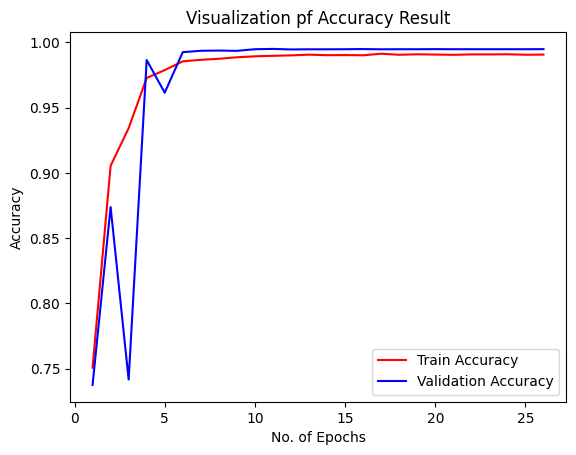

In [31]:
plt.plot(epochs,training_history.history["accuracy"]  ,color ="r" ,label ="Train Accuracy")
plt.plot(epochs , training_history.history["val_accuracy"]  , color ="b" , label ="Validation Accuracy")
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")
plt.title("Visualization pf Accuracy Result")
plt.legend()
plt.show()

###  Other metrics for model evaluation

In [32]:
class_name = validation_set.class_names

In [33]:
train_set  =  tf.keras.utils.image_dataset_from_directory(
    "../data/ PlantDisease/Dataset/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 17572 files belonging to 38 classes.


In [34]:
y_pred = model.predict(train_set)
predicted_categories = tf.argmax(y_pred,axis = 1)

17572/17572 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step


In [35]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [36]:
true_categories = tf.concat([ y for x ,y in train_set] ,axis = 0)
y_true = tf.argmax(true_categories ,axis =1)

In [37]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_true , predicted_categories , target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       504
                                 Apple___Black_rot       1.00      1.00      1.00       497
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       440
                                   Apple___healthy       0.99      1.00      1.00       502
                               Blueberry___healthy       0.99      1.00      1.00       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.95      0.96       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.99      0.

### Confusion Matrix Visualization

In [38]:
cm = confusion_matrix(y_true , predicted_categories)
cm.shape

(38, 38)

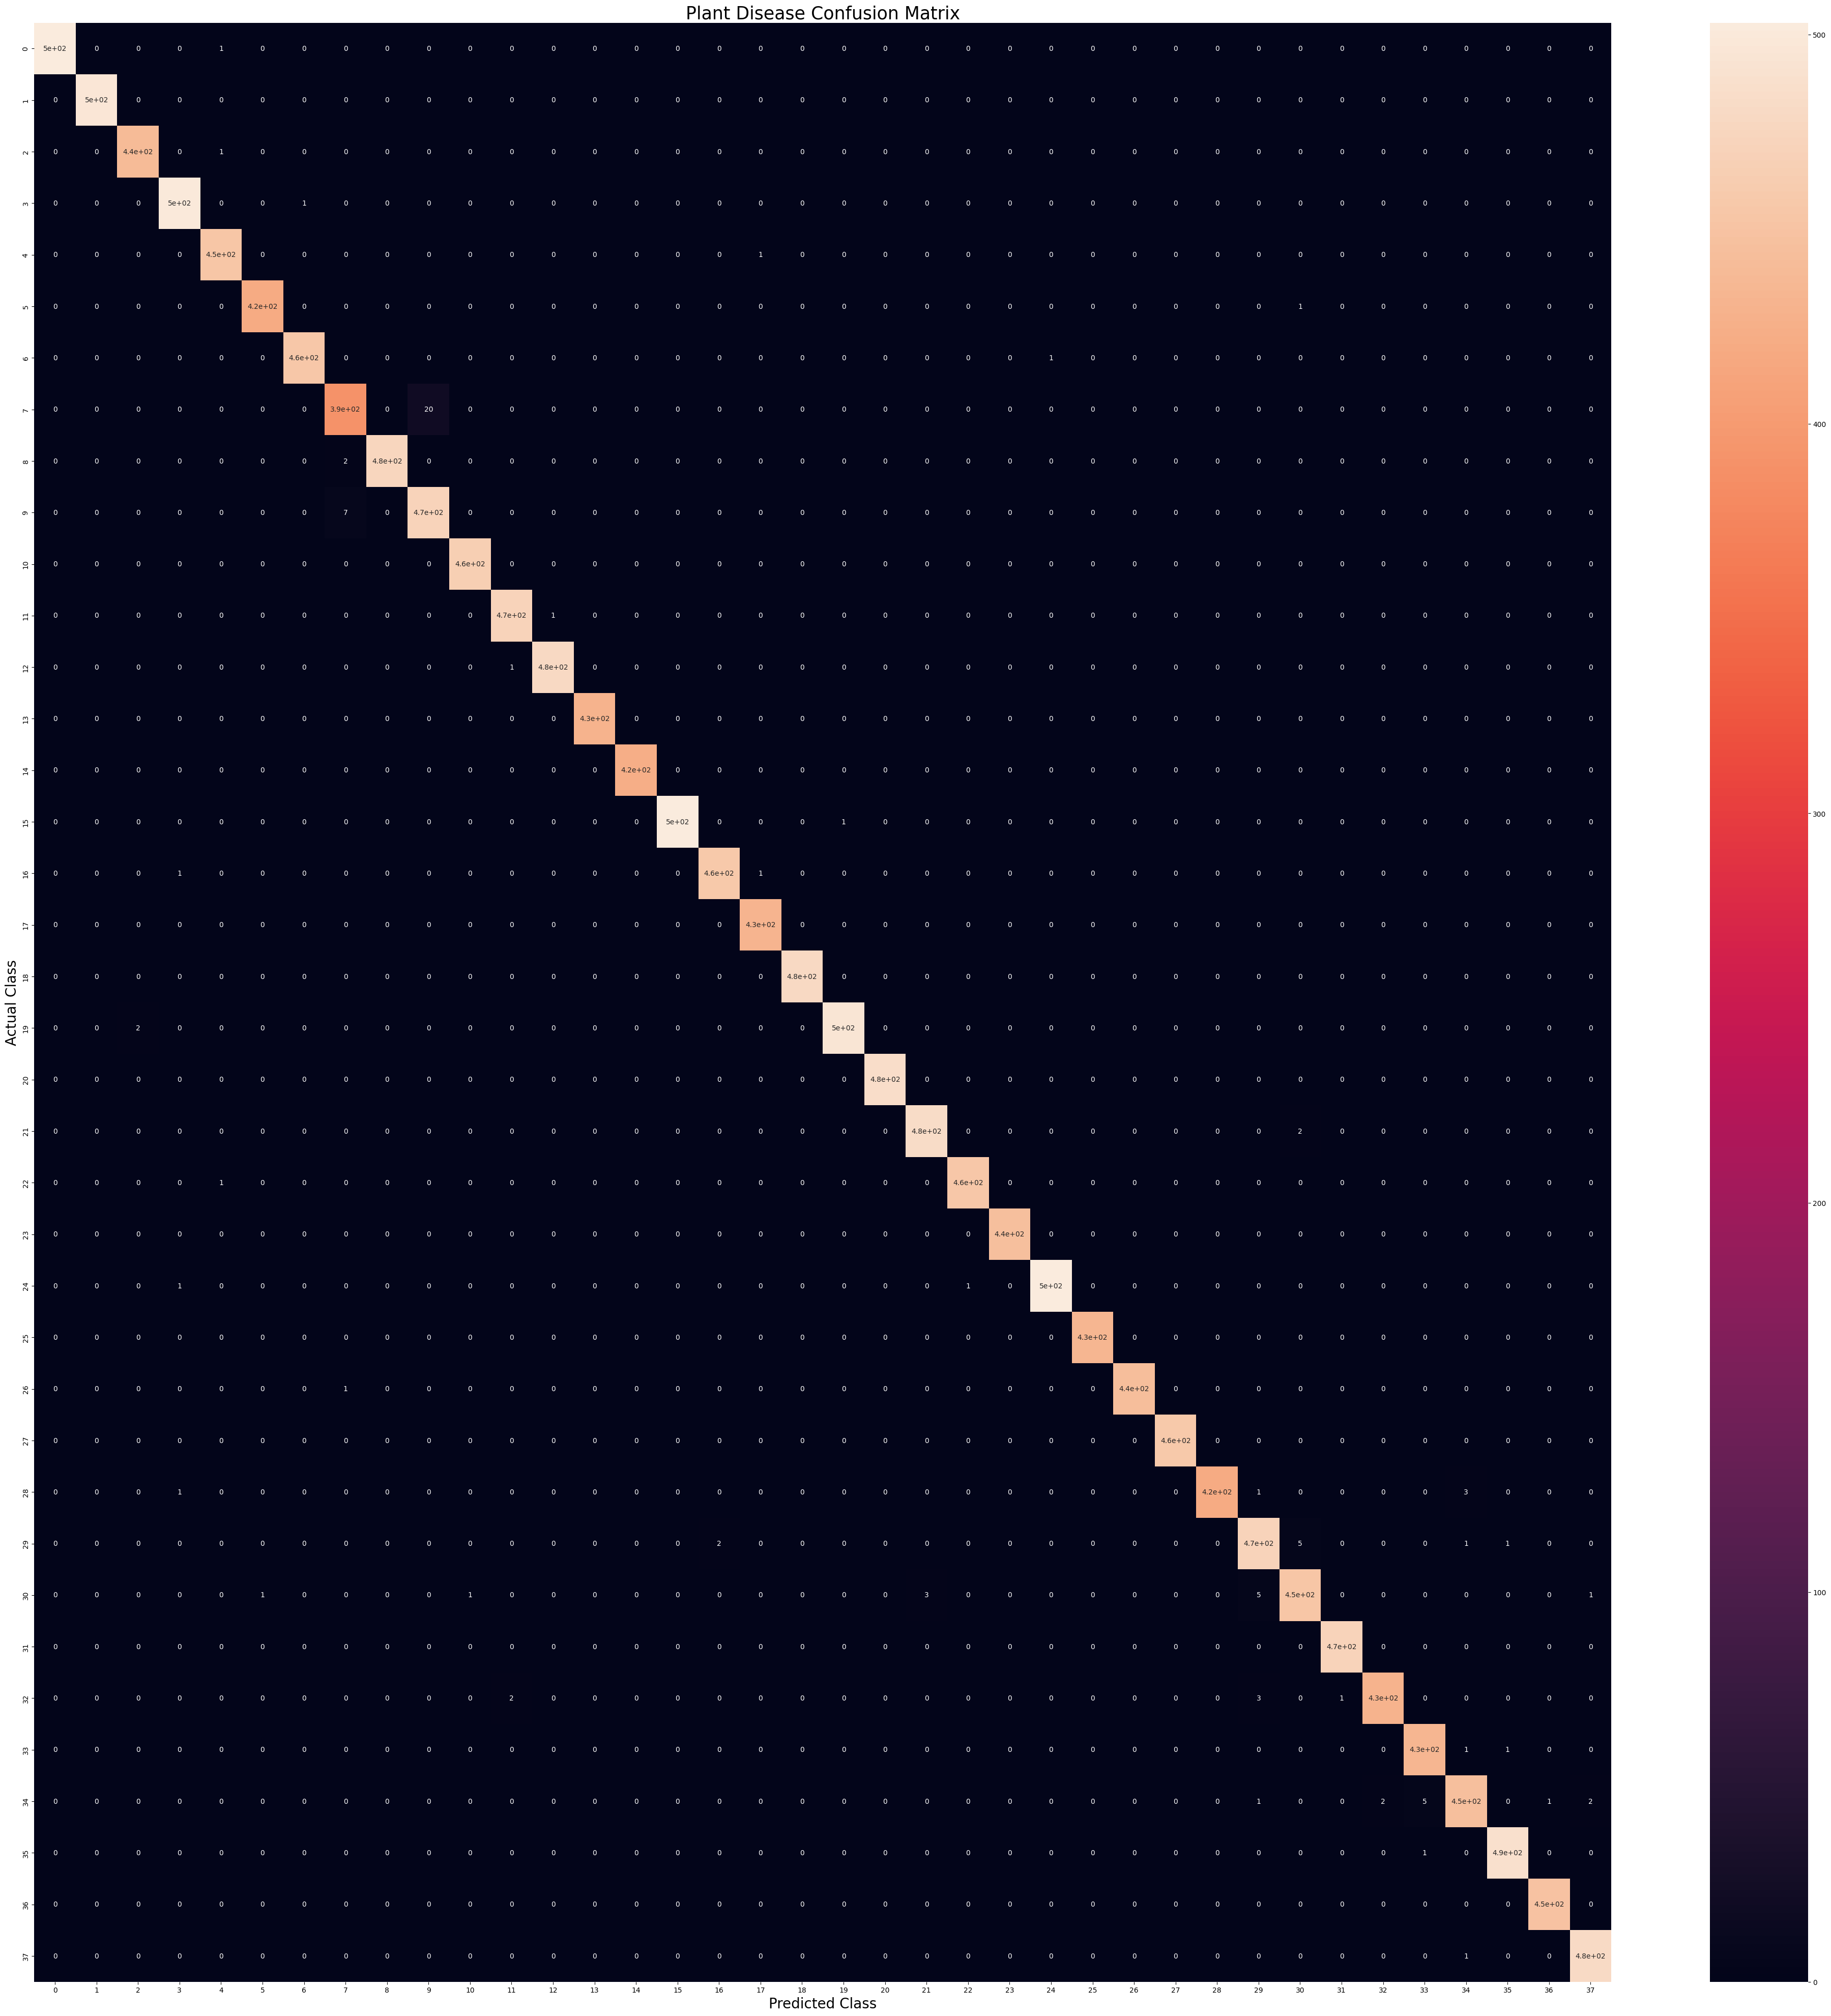

In [39]:
plt.figure(figsize=(50, 50))
plt.title("Plant Disease Confusion Matrix",fontsize=25)
sns.heatmap(cm ,annot=True , annot_kws={"size" :10})
plt.xlabel("Predicted Class" ,fontsize =20)
plt.ylabel("Actual Class",fontsize =20)
plt.show()